# 01 - Analiza skupa podataka

## Vision-Language Clothing Retrieval

Ova Jupyter sveska predstavlja osnovnu analizu skupa podataka koji se koristi u projektu **Vision-Language Clothing Retrieval**.

Cilj analize je da se ispita struktura i kvalitet podataka koji se koriste za multimodalnu pretragu odeće, sa posebnim osvrtom na:

- ukupan broj uzoraka,
- validnost tekstualnih opisa,
- strukturu pojedinačnog uzorka,
- dužinu tekstualnih opisa,
- raspodelu podataka na train, validation i test skup,
- odnose između slika i artikala,
- primere slika i njihovih tekstualnih opisa.

Analiza koristi postojeći `DeepFashionDatasetLoader` iz projektnog koda kako bi se obezbedila konzistentnost između analize i glavnog pipeline-a.

In [12]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from vision_language_clothing_retrieval.dataset.deepfashion import (
    DeepFashionDatasetLoader,
)
from vision_language_clothing_retrieval.dataset.preprocessing import (
    split_samples,
)


## 1. Učitavanje skupa podataka

Podaci se učitavaju pomoću `DeepFashionDatasetLoader` klase koja povezuje slike sa odgovarajućim tekstualnim opisima.

Svaki uzorak sadrži:

- jedinstveni identifikator,
- putanju do slike,
- tekstualni opis.

In [14]:
DATA_DIR = Path("../data")

IMAGES_DIR = DATA_DIR / "images"
CAPTIONS_PATH = DATA_DIR / "captions.json"

loader = DeepFashionDatasetLoader(
    str(IMAGES_DIR),
    str(CAPTIONS_PATH),
)

samples = list(loader.load())

print(f"Ukupan broj učitanih uzoraka: {len(samples):,}")


Ukupan broj učitanih uzoraka: 42,544
Ukupan broj učitanih uzoraka: 42,544


In [16]:
empty_caption_samples = [
    sample for sample in samples
    if not sample.text.strip()
]

valid_samples = [
    sample for sample in samples
    if sample.text.strip()
]

total_samples = len(samples)
empty_count = len(empty_caption_samples)
valid_count = len(valid_samples)

print(f"Ukupno uzoraka:          {total_samples:,}")
print(f"Sa praznim captionom:    {empty_count:,}")
print(f"Validnih uzoraka:        {valid_count:,}")
print(f"Udeo validnih uzoraka:   {valid_count / total_samples:.2%}")


Ukupno uzoraka:          42,544
Sa praznim captionom:    7
Validnih uzoraka:        42,537
Udeo validnih uzoraka:   99.98%
Ukupno uzoraka:          42,544
Sa praznim captionom:    7
Validnih uzoraka:        42,537
Udeo validnih uzoraka:   99.98%


### Kvalitet podataka

Od ukupno 42.544 učitana uzorka, 42.537 ima neprazan tekstualni opis.

Samo 7 uzoraka nema caption. Ovi uzorci se ne uključuju u konačnu podelu na train, validation i test skupove, jer tekstualna komponenta takvih uzoraka nije pogodna za generisanje text embeddinga.

Na ovaj način se za dalju multimodalnu obradu koristi 42.537 validnih image-caption uzoraka.

## 2. Struktura pojedinačnog uzorka

Svaki uzorak je predstavljen pomoću `DatasetSample` dataklase.

U nastavku je prikazan jedan reprezentativan uzorak iz skupa podataka.

In [18]:
sample = valid_samples[0]

print("Sample ID")
print(sample.sample_id)

print("\nPutanja do slike")
print(sample.image_path)

print("\nCaption")
print(sample.text)


Sample ID
MEN-Denim-id_00000080-01_7_additional

Putanja do slike
..\data\images\MEN-Denim-id_00000080-01_7_additional.jpg

Caption
The lower clothing is of long length. The fabric is cotton and it has plaid patterns.
Sample ID
MEN-Denim-id_00000080-01_7_additional

Putanja do slike
..\data\images\MEN-Denim-id_00000080-01_7_additional.jpg

Caption
The lower clothing is of long length. The fabric is cotton and it has plaid patterns.


## 3. Analiza tekstualnih opisa

Pored postojanja captiona, analizirana je i njihova dužina.

Dužina captiona posmatra se kroz broj reči, što omogućava uvid u količinu tekstualne informacije koja je dostupna za svaki uzorak.

In [20]:
caption_lengths = [
    len(sample.text.split())
    for sample in valid_samples
]

caption_stats = pd.Series(caption_lengths).describe()

caption_stats = pd.DataFrame(
    {
        "Vrednost": [
            int(caption_stats["count"]),
            caption_stats["mean"],
            caption_stats["std"],
            int(caption_stats["min"]),
            int(caption_stats["25%"]),
            int(caption_stats["50%"]),
            int(caption_stats["75%"]),
            int(caption_stats["max"]),
        ]
    },
    index=[
        "Broj uzoraka",
        "Prosečna dužina",
        "Standardna devijacija",
        "Minimum",
        "25. percentil",
        "Medijana",
        "75. percentil",
        "Maksimum",
    ],
)

caption_stats.round(2)

,Vrednost
Broj uzoraka,42537.00
Prosečna dužina,40.45
Standardna devijacija,13.78
Minimum,4.00
25. percentil,30.00
Medijana,41.00
75. percentil,51.00
Maksimum,93.00


,Vrednost
Broj uzoraka,42537.00
Prosečna dužina,40.45
Standardna devijacija,13.78
Minimum,4.00
25. percentil,30.00
Medijana,41.00
75. percentil,51.00
Maksimum,93.00


### Rezultati analize dužine captiona

Validni tekstualni opisi u proseku sadrže 40,45 reči, dok je medijalna dužina 41 reč.

Polovina captiona sadrži između 30 i 51 reči. Najkraći caption ima 4 reči, dok najduži ima 93 reči.

Standardna devijacija od 13,78 reči ukazuje na umerenu varijaciju u dužini tekstualnih opisa. Captioni stoga sadrže relativno konzistentnu količinu tekstualne informacije, uz postojanje kraćih i dužih opisa.

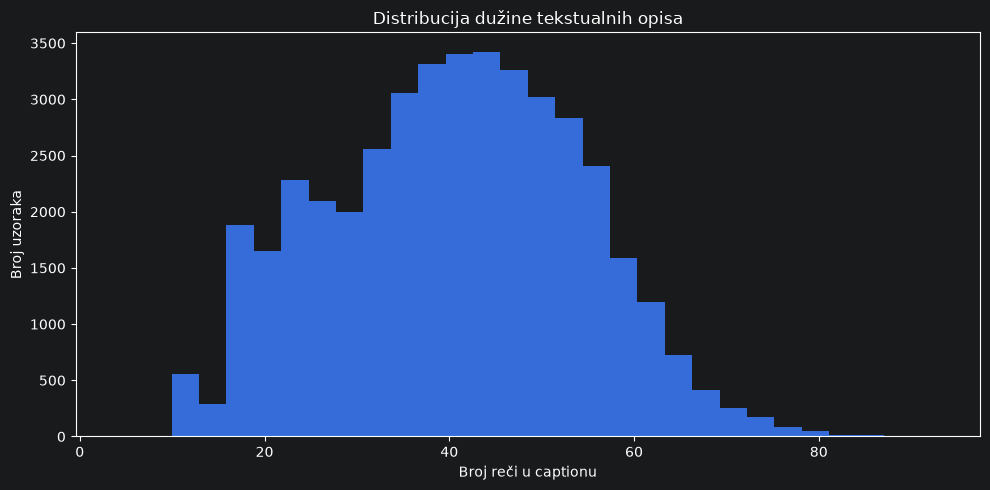

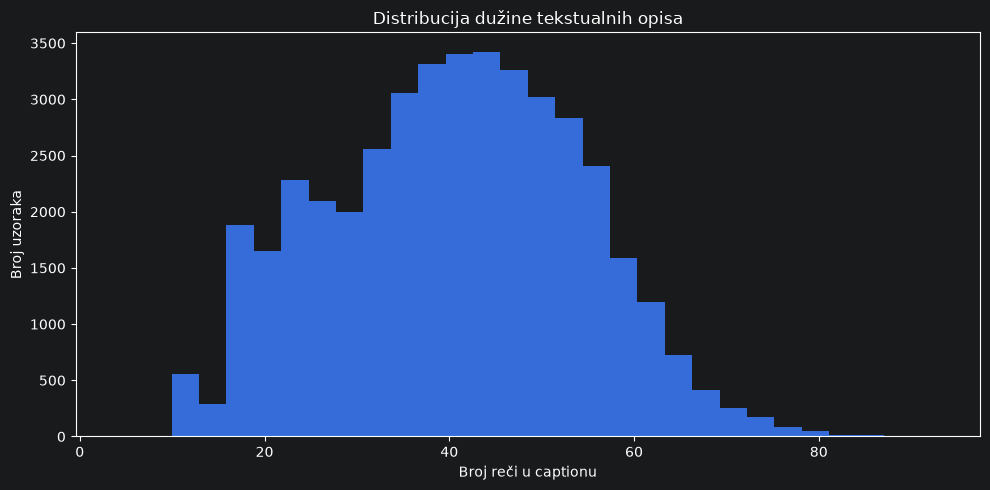

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(
    caption_lengths,
    bins=30,
)

plt.xlabel("Broj reči u captionu")
plt.ylabel("Broj uzoraka")
plt.title("Distribucija dužine tekstualnih opisa")

plt.tight_layout()
plt.show()


### Distribucija dužine captiona

Histogram prikazuje raspodelu broja reči u tekstualnim opisima.

Ova analiza daje osnovni uvid u količinu tekstualne informacije dostupne modelu za generisanje text embeddinga.

## 4. Podela skupa podataka

Validni uzorci dele se na train, validation i test skup.

Podela se vrši na nivou artikla, a ne nezavisno na nivou slike. Ovo je važno zato što isti komad odeće može imati više različitih prikaza.

Na taj način se sprečava da različite slike istog artikla završe u različitim podskupovima i izazovu data leakage.

In [24]:
train_samples, validation_samples, test_samples = split_samples(
    valid_samples
)

split_sizes = pd.Series(
    {
        "Train": len(train_samples),
        "Validation": len(validation_samples),
        "Test": len(test_samples),
    }
)

split_sizes


Train         34047
Validation     4354
Test           4136
dtype: int64

Train         34047
Validation     4354
Test           4136
dtype: int64

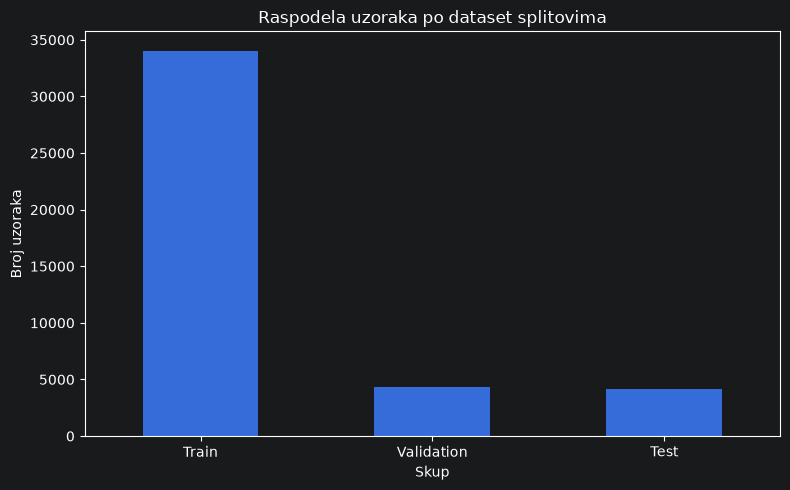

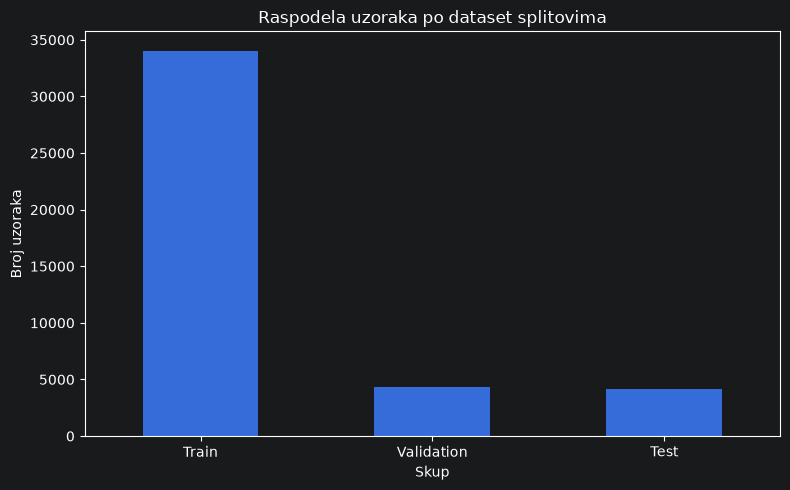

In [26]:
plt.figure(figsize=(8, 5))

split_sizes.plot(kind="bar")

plt.xlabel("Skup")
plt.ylabel("Broj uzoraka")
plt.title("Raspodela uzoraka po dataset splitovima")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Veličina dataset splitova

| Skup | Broj uzoraka |
|---|---:|
| Train | 34.047 |
| Validation | 4.354 |
| Test | 4.136 |
| **Ukupno** | **42.537** |

Train skup predstavlja najveći deo podataka i koristi se za razvoj modela, dok validation i test skup služe za evaluaciju i proveru generalizacije.

In [28]:
train_ids = {sample.sample_id for sample in train_samples}
validation_ids = {sample.sample_id for sample in validation_samples}
test_ids = {sample.sample_id for sample in test_samples}

train_validation_overlap = train_ids & validation_ids
train_test_overlap = train_ids & test_ids
validation_test_overlap = validation_ids & test_ids

print(f"Train ∩ Validation: {len(train_validation_overlap)}")
print(f"Train ∩ Test:       {len(train_test_overlap)}")
print(f"Validation ∩ Test:  {len(validation_test_overlap)}")


Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0


### Provera preklapanja

Nakon podele izvršena je programska provera identifikatora uzoraka.

Nijedan uzorak se ne pojavljuje istovremeno u dva različita podskupa. Time je potvrđeno da između train, validation i test skupa nema preklapanja na nivou `sample_id`.

Dodatno, sama podela se vrši na nivou artikla kako bi se sprečilo da različiti prikazi istog komada odeće završe u različitim podskupovima.

## 5. Primeri slika i tekstualnih opisa

U nastavku je prikazano nekoliko reprezentativnih primera iz skupa podataka.

Za svaki primer prikazani su slika i odgovarajući tekstualni opis.

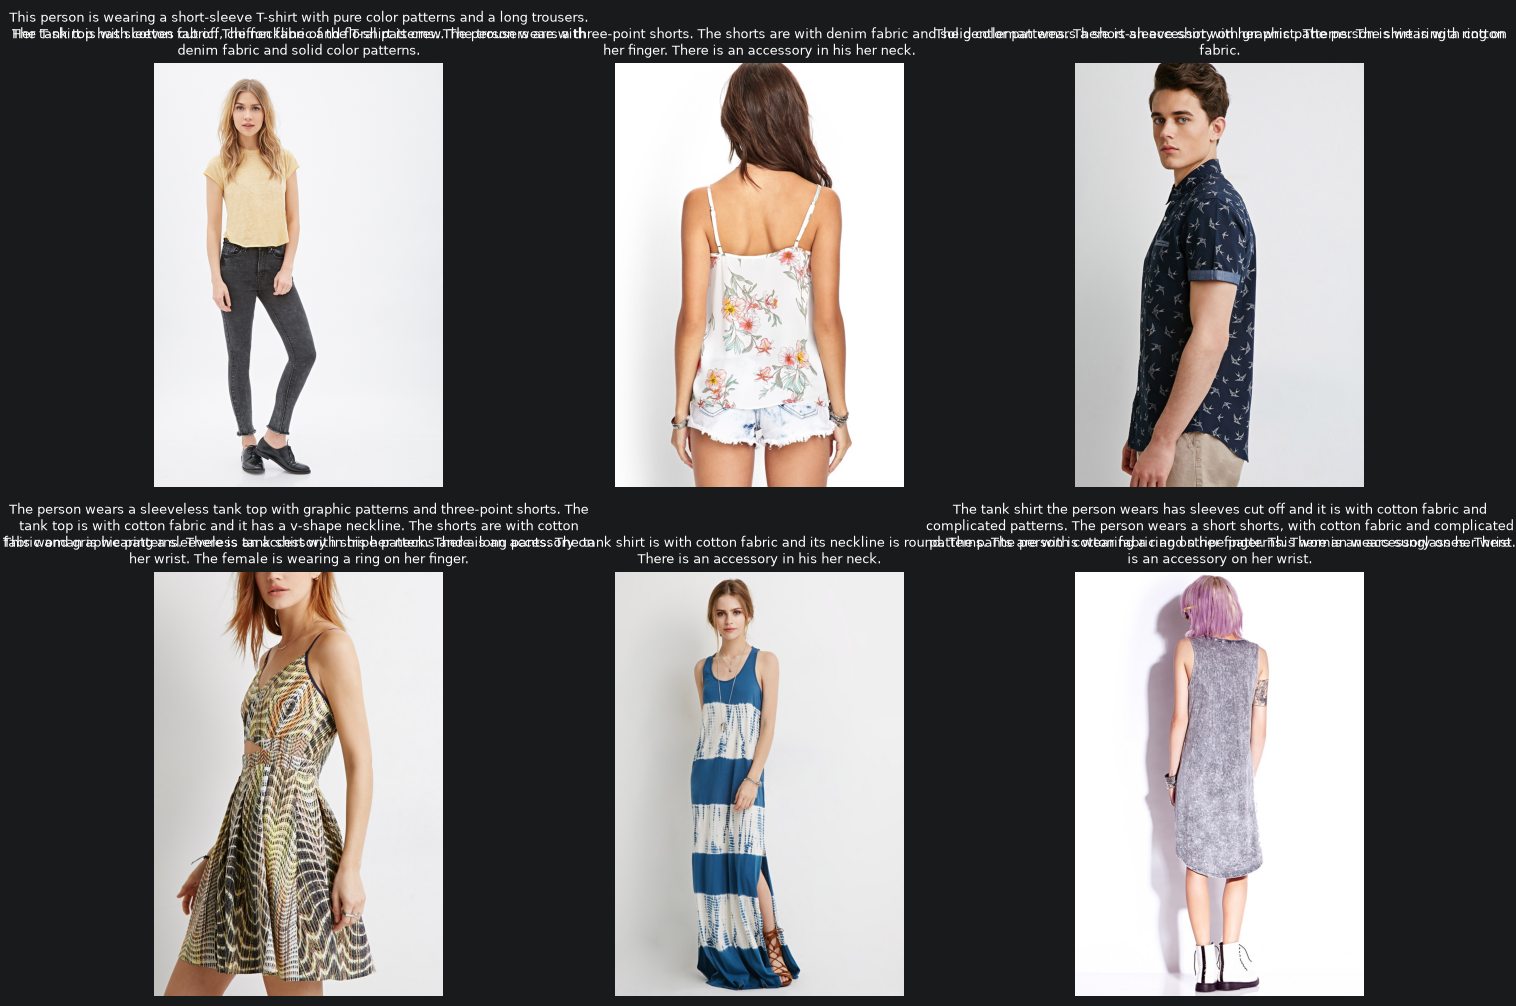

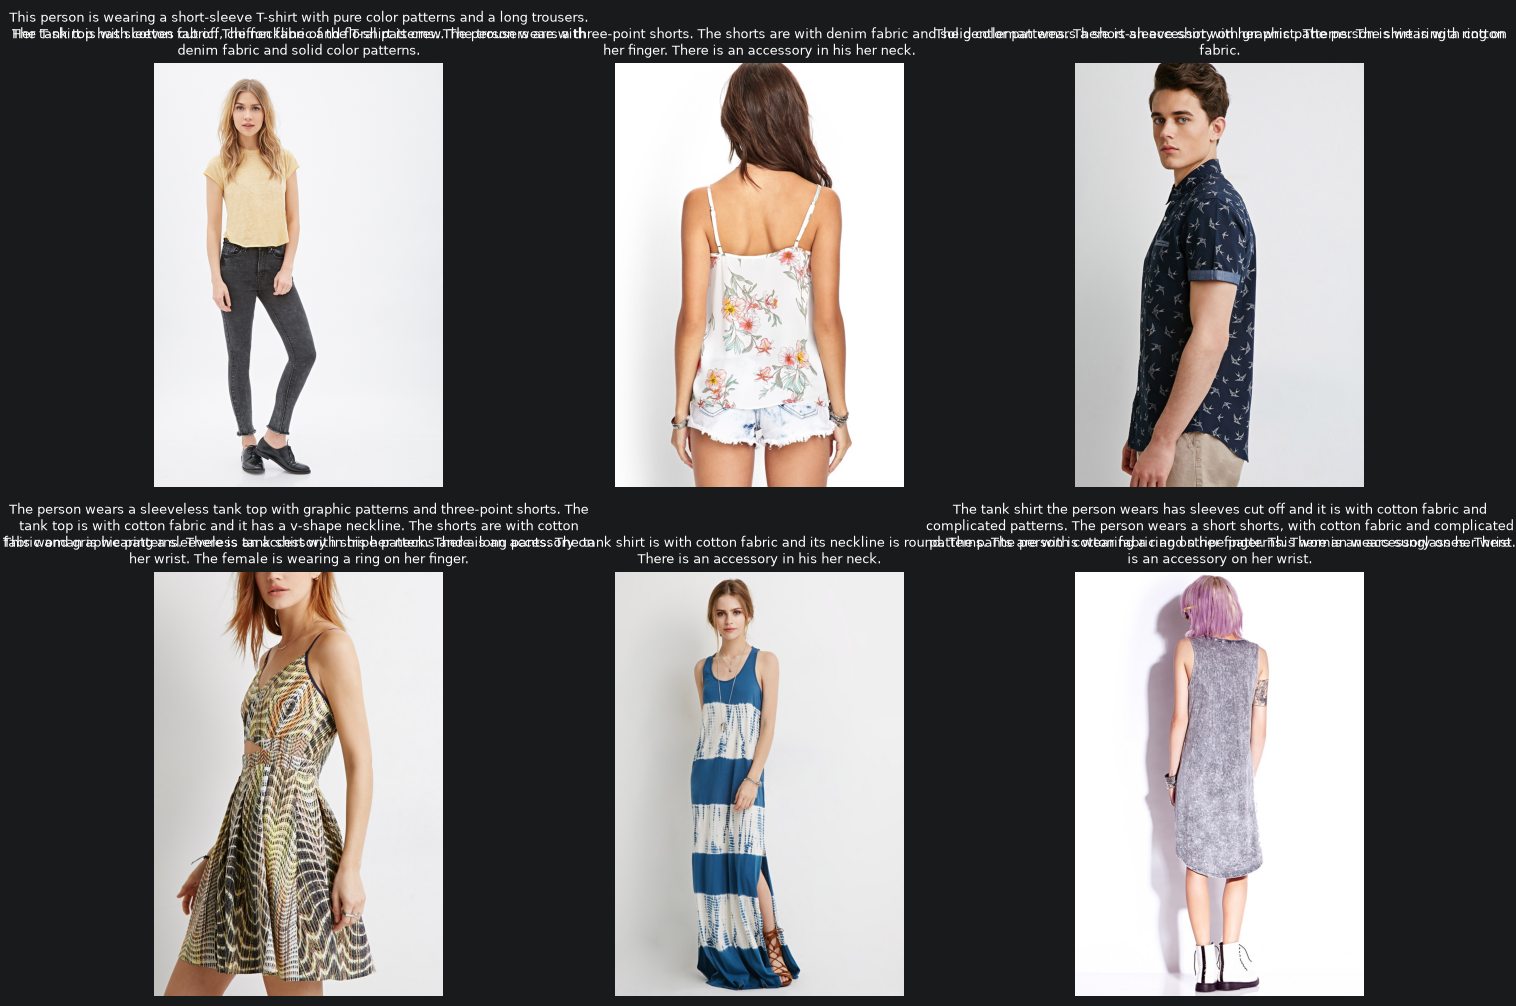

In [30]:
import random

random.seed(42)

example_samples = random.sample(valid_samples, 6)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

for ax, sample in zip(axes.flat, example_samples):
    image = Image.open(sample.image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        sample.text,
        fontsize=9,
        wrap=True,
    )

plt.tight_layout()
plt.show()


## 6. Zaključak

Analizirani skup podataka sadrži 42.544 image-caption uzorka, od kojih je 42.537 validno za dalju multimodalnu obradu.

Utvrđeno je da:

- skup sadrži 42.544 učitana uzorka,
- 7 uzoraka ima prazan caption,
- 42.537 uzoraka ima validan tekstualni opis,
- validni uzorci su podeljeni na train, validation i test skup,
- između podskupova ne postoji preklapanje,
- podela se vrši na nivou artikla kako bi se sprečio data leakage,
- tekstualni opisi imaju različite dužine, čija je distribucija analizirana,
- prikazani su reprezentativni primeri slika i njihovih tekstualnih opisa.

Ova analiza predstavlja osnovu za naredne faze projekta, odnosno generisanje multimodalnih embeddinga i razvoj retrieval sistema.
